# 🛡️ Sales Invoice Anomaly & Fraud Detection Engine
### Unsupervised Transaction Auditing via Isolation Forest

This pipeline builds an unsupervised machine learning model to detect anomalous, fraudulent, or errant sales invoices in B2B transactions.

---

### 📌 The 13 Production Features Matrix:

1. **`invoice_amount`**: Total transaction value ($grand\_total$).
2. **`discount_ratio`**: Proportion of discount granted relative to subtotal ($discount\_total / subtotal$).
3. **`paid_ratio`**: Proportion of the invoice paid immediately upfront ($amount\_paid / invoice\_amount$).
4. **`due_ratio`**: Proportion of debt left unpaid on credit ($balance\_due / invoice\_amount$).
5. **`invoice_vs_customer_avg`**: Ratio of current invoice amount to customer's historical average.
6. **`invoice_vs_customer_max`**: Ratio of current invoice amount to customer's historical maximum purchase.
7. **`customer_invoice_frequency`**: Average count of invoices issued per month for this customer.
8. **`days_since_last_invoice`**: Elapsed days since the customer's previous invoice.
9. **`customer_discount_avg`**: Customer's historical average discount rate.
10. **`discount_vs_normal`**: Deviation between current discount ratio and customer's baseline discount rate.
11. **`credit_utilization_ratio`**: Ratio of invoice amount to customer's assigned credit limit.
12. **`items_count`**: Number of distinct line items contained within the invoice.
13. **`average_item_price`**: Mean unit price of items in the invoice (detects barcode manipulation/mislabeled items).

> *Note: Time-of-day features (hour and off-hours flags) were explicitly excluded to preserve high signal on B2B calendar invoice data.*

In [9]:
import os
import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Visualization and styling defaults
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## 1. 📂 Data Ingestion & Sanitization
Loading the invoice transaction dataset and validating data types, dates, and structural consistency.

In [10]:
DATA_PATH = '../data/raw_invoice_anomaly_dataset.csv'
df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset Dimensions: {df_raw.shape[0]:,} rows | {df_raw.shape[1]} columns")
df_raw.head(3)

Dataset Dimensions: 138,164 rows | 15 columns


,invoice_id,sales_order_id,customer_id,product_id,customer_segment,credit_limit,invoice_date,due_date,invoice_amount,amount_paid,balance_due,invoice_status,subtotal,discount_total,unit_price
0,INV-0000001,SO-0000004,CUST-000025,PROD-001163,Enterprise,289034.44,2024-01-04,2024-02-18,54.79,54.79,0.0,Paid,36.99,5.73,7.12
1,INV-0000002,SO-0000005,CUST-000045,PROD-000545,Enterprise,159350.88,2024-01-01,2024-03-01,39.55,39.55,0.0,Paid,24.44,4.16,7.15
2,INV-0000003,SO-0000007,CUST-000054,PROD-001009,Enterprise,198997.42,2024-01-01,2024-03-01,3489.91,3489.91,0.0,Paid,3489.91,459.29,789.84


### 1.1 Temporal & String Cleaning
Standardizing dates to pandas `datetime` format, sorting chronologically by customer to enable historical calculations, and stripping whitespace from string columns.

In [11]:
def clean_invoice_data(df: pd.DataFrame) -> pd.DataFrame:
    data = df.copy()
    
    # 1. Parse date fields safely
    data['invoice_date'] = pd.to_datetime(data['invoice_date'], format='mixed')
    data['due_date'] = pd.to_datetime(data['due_date'], format='mixed')
    
    # 2. Sort chronologically per customer to compute lag & rolling features correctly
    data = data.sort_values(by=['customer_id', 'invoice_date']).reset_index(drop=True)
    
    # 3. Clean accidental whitespace in categorical fields
    if 'customer_segment' in data.columns:
        data['customer_segment'] = data['customer_segment'].astype(str).str.strip()
    if 'invoice_status' in data.columns:
        data['invoice_status'] = data['invoice_status'].astype(str).str.strip()
        
    return data

df_clean = clean_invoice_data(df_raw)
print(f"✅ Cleaning complete. Temporal span: {df_clean['invoice_date'].min().date()} to {df_clean['invoice_date'].max().date()}")

✅ Cleaning complete. Temporal span: 2024-01-01 to 2025-12-31


## 2. ⚙️ Feature Engineering (The 13 Core Anomaly Indicators)
In this section, we compute financial ratios, basket-level metrics, and customer behavioral baselines.

In [12]:
FEATURE_NAMES = [
    'invoice_amount',              # 1. Total transaction value
    'discount_ratio',              # 2. Discount proportion on subtotal
    'paid_ratio',                  # 3. Upfront payment proportion
    'due_ratio',                   # 4. Unpaid debt proportion
    'invoice_vs_customer_avg',     # 5. Amount vs customer historical average
    'invoice_vs_customer_max',     # 6. Amount vs customer historical peak
    'customer_invoice_frequency',  # 7. Customer monthly invoice frequency
    'days_since_last_invoice',     # 8. Days elapsed since previous invoice
    'customer_discount_avg',       # 9. Customer baseline discount rate
    'discount_vs_normal',          # 10. Discount deviation from customer baseline
    'credit_utilization_ratio',    # 11. Credit limit consumption ratio
    'items_count',                 # 12. Distinct item count in invoice
    'average_item_price'           # 13. Average unit price of items in invoice
]

def extract_anomaly_features(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extracts the 13 financial and behavioral anomaly indicators.
    Returns:
        invoices_df: Unique invoice-level DataFrame with metadata
        X: Model-ready feature matrix (strictly the 13 numerical columns)
    """
    data = df.copy()
    eps = 1e-5
    
    # --- 1. Direct Invoice-Level Financial Ratios ---
    data['discount_ratio'] = np.where(
        data['subtotal'] > 0,
        (data['discount_total'] / (data['subtotal'] + eps)).clip(0.0, 1.0),
        0.0
    )
    data['paid_ratio'] = np.where(
        data['invoice_amount'] > 0,
        (data['amount_paid'] / (data['invoice_amount'] + eps)).clip(0.0, 1.0),
        0.0
    )
    data['due_ratio'] = np.where(
        data['invoice_amount'] > 0,
        (data['balance_due'] / (data['invoice_amount'] + eps)).clip(0.0, 1.0),
        0.0
    )
    data['credit_utilization_ratio'] = data['invoice_amount'] / (data['credit_limit'] + eps)
    
    # --- 2. Line Items & Internal Basket Pricing ---
    inv_group = data.groupby('invoice_id')
    data['items_count'] = inv_group['product_id'].transform('count')
    data['average_item_price'] = inv_group['unit_price'].transform('mean')
    
    # --- 3. Customer Historical & Behavioral Baselines ---
    cust_group = data.groupby('customer_id')
    cust_avg_inv = cust_group['invoice_amount'].transform('mean')
    cust_max_inv = cust_group['invoice_amount'].transform('max')
    
    data['invoice_vs_customer_avg'] = data['invoice_amount'] / (cust_avg_inv + eps)
    data['invoice_vs_customer_max'] = data['invoice_amount'] / (cust_max_inv + eps)
    
    # Days elapsed since previous invoice for this customer
    data['days_since_last_invoice'] = cust_group['invoice_date'].diff().dt.total_seconds() / 86400.0
    data['days_since_last_invoice'] = data['days_since_last_invoice'].fillna(999.0).clip(lower=0.0)
    
    # Monthly invoice velocity
    cust_first_date = cust_group['invoice_date'].transform('min')
    cust_last_date = cust_group['invoice_date'].transform('max')
    tenure_months = (((cust_last_date - cust_first_date).dt.days) / 30.0).clip(lower=1.0)
    cust_total_invs = cust_group['invoice_id'].transform('nunique')
    data['customer_invoice_frequency'] = cust_total_invs / tenure_months
    
    # Customer baseline discount rate & current deviation
    data['customer_discount_avg'] = cust_group['discount_ratio'].transform('mean')
    data['discount_vs_normal'] = data['discount_ratio'] - data['customer_discount_avg']
    
    # Deduplicate to ensure one record per invoice
    invoices_df = data.drop_duplicates(subset=['invoice_id']).copy().reset_index(drop=True)
    
    # Extract feature matrix X and sanitize non-finite values
    X = invoices_df[FEATURE_NAMES].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    
    return invoices_df, X

df_invoices, X = extract_anomaly_features(df_clean)
print(f"🎯 Features successfully computed for {len(X):,} distinct invoices.")
X.describe().T[['mean', 'std', 'min', '50%', 'max']]

🎯 Features successfully computed for 72,800 distinct invoices.


,mean,std,min,50%,max
invoice_amount,997.453704,2065.619615,13.020000,368.835000,144076.390000
discount_ratio,0.088321,0.065462,0.000000,0.079444,0.419117
paid_ratio,0.972943,0.156094,0.000000,1.000000,1.000000
due_ratio,0.027057,0.156094,0.000000,0.000000,1.000000
invoice_vs_customer_avg,0.783115,1.252458,0.001416,0.333403,49.718796
invoice_vs_customer_max,0.186453,0.268170,0.000098,0.068924,1.000000
customer_invoice_frequency,1.658613,0.973930,0.164384,1.390728,7.009346
days_since_last_invoice,81.338723,223.869143,0.000000,16.000000,999.000000
customer_discount_avg,0.088190,0.058087,0.000000,0.079726,0.275794
discount_vs_normal,0.000131,0.030190,-0.163943,-0.002191,0.178905


## 3. 📊 Exploratory Data Analysis (EDA) & Feature Distributions
Inspecting statistical properties, skewed distributions with extreme outliers, and feature correlations.

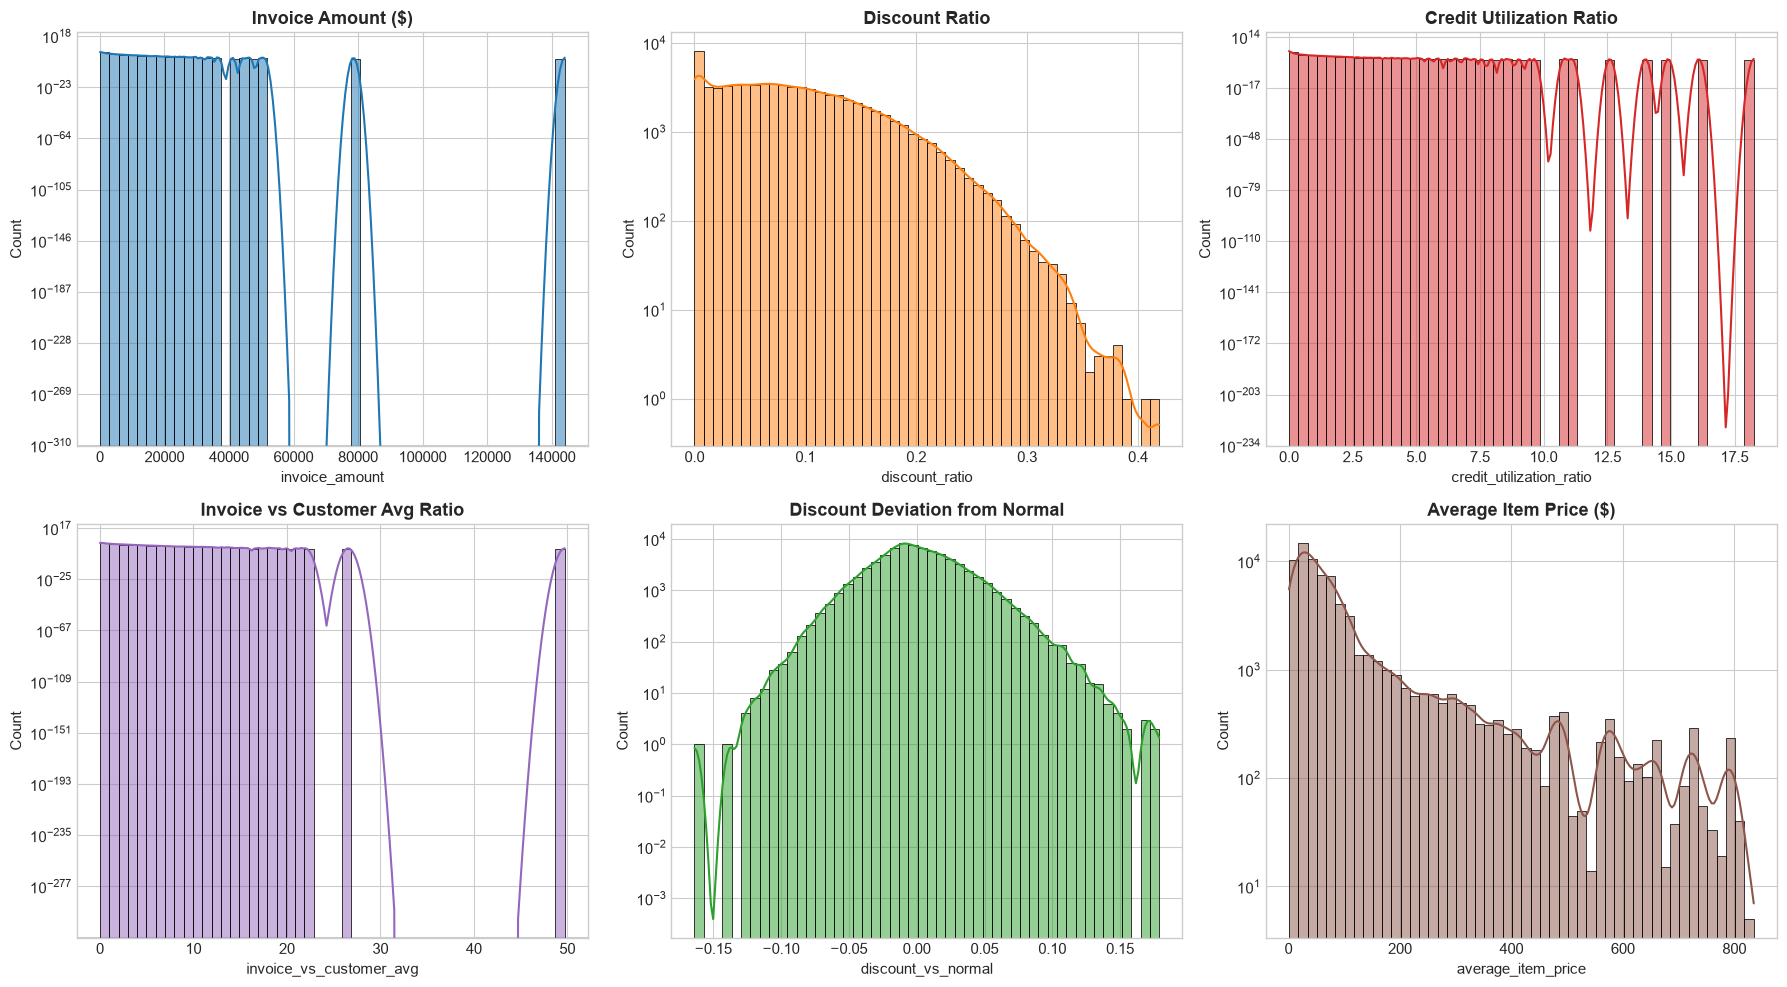

In [13]:
# Plotting distributions of key anomaly-sensitive features on a logarithmic scale
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

key_features = [
    ('invoice_amount', 'Invoice Amount ($)', '#1f77b4'),
    ('discount_ratio', 'Discount Ratio', '#ff7f0e'),
    ('credit_utilization_ratio', 'Credit Utilization Ratio', '#d62728'),
    ('invoice_vs_customer_avg', 'Invoice vs Customer Avg Ratio', '#9467bd'),
    ('discount_vs_normal', 'Discount Deviation from Normal', '#2ca02c'),
    ('average_item_price', 'Average Item Price ($)', '#8c564b')
]

for idx, (col, title, color) in enumerate(key_features):
    ax = axes[idx // 3, idx % 3]
    sns.histplot(X[col], bins=50, kde=True, ax=ax, color=color)
    ax.set_title(title, fontweight='bold')
    ax.set_yscale('log') # Log scale highlights the extreme tail outliers

plt.tight_layout()
plt.show()

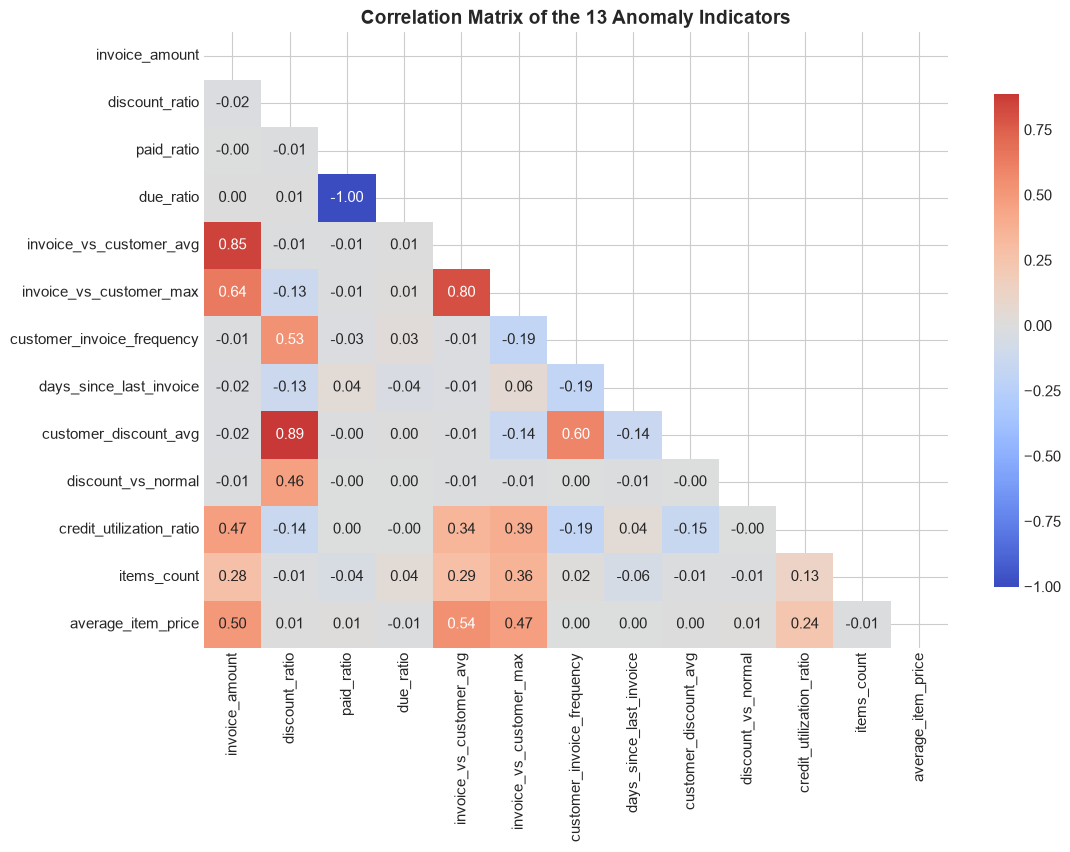

In [14]:
# Feature Correlation Matrix
plt.figure(figsize=(12, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={"shrink": .8})
plt.title("Correlation Matrix of the 13 Anomaly Indicators", fontsize=14, fontweight='bold')
plt.show()

## 4. 🤖 Model Pipeline: RobustScaler & Isolation Forest
We build an end-to-end scikit-learn `Pipeline` combining:
1. **`RobustScaler`**: Centers data by median and scales by IQR, protecting the feature scaling from being distorted by massive fraud outliers.
2. **`IsolationForest`**: Ensembles 200 isolation trees to partition feature space; anomalies require fewer splits and are isolated close to tree roots.
   - `contamination=0.03`: Assumes approximately 3% anomalous transactions.

In [15]:
pipeline = Pipeline([
    ('scaler', RobustScaler()),
    ('model', IsolationForest(
        n_estimators=200,
        contamination=0.03,
        max_samples='auto',
        random_state=42,
        n_jobs=-1
    ))
])

print("⏳ Training Isolation Forest anomaly pipeline...")
pipeline.fit(X)

# Binary anomaly prediction: 1 = Normal, -1 = Anomaly
df_invoices['anomaly_prediction'] = pipeline.predict(X)
# Continuous anomaly score: lower/negative values represent more severe anomalies
df_invoices['anomaly_score'] = pipeline.decision_function(X)

anomalies_count = (df_invoices['anomaly_prediction'] == -1).sum()
normal_count = (df_invoices['anomaly_prediction'] == 1).sum()
pct = (anomalies_count / len(df_invoices)) * 100

print("✅ Training complete.")
print(f"🚨 Anomalies Flagged: {anomalies_count:,} ({pct:.2f}%)")
print(f"🟢 Normal Transactions: {normal_count:,}")

⏳ Training Isolation Forest anomaly pipeline...
✅ Training complete.
🚨 Anomalies Flagged: 2,184 (3.00%)
🟢 Normal Transactions: 70,616


## 5. 🔍 Anomaly Diagnostics & 2D PCA Projections
We evaluate how distinct the flagged anomalies are from legitimate baseline transactions.

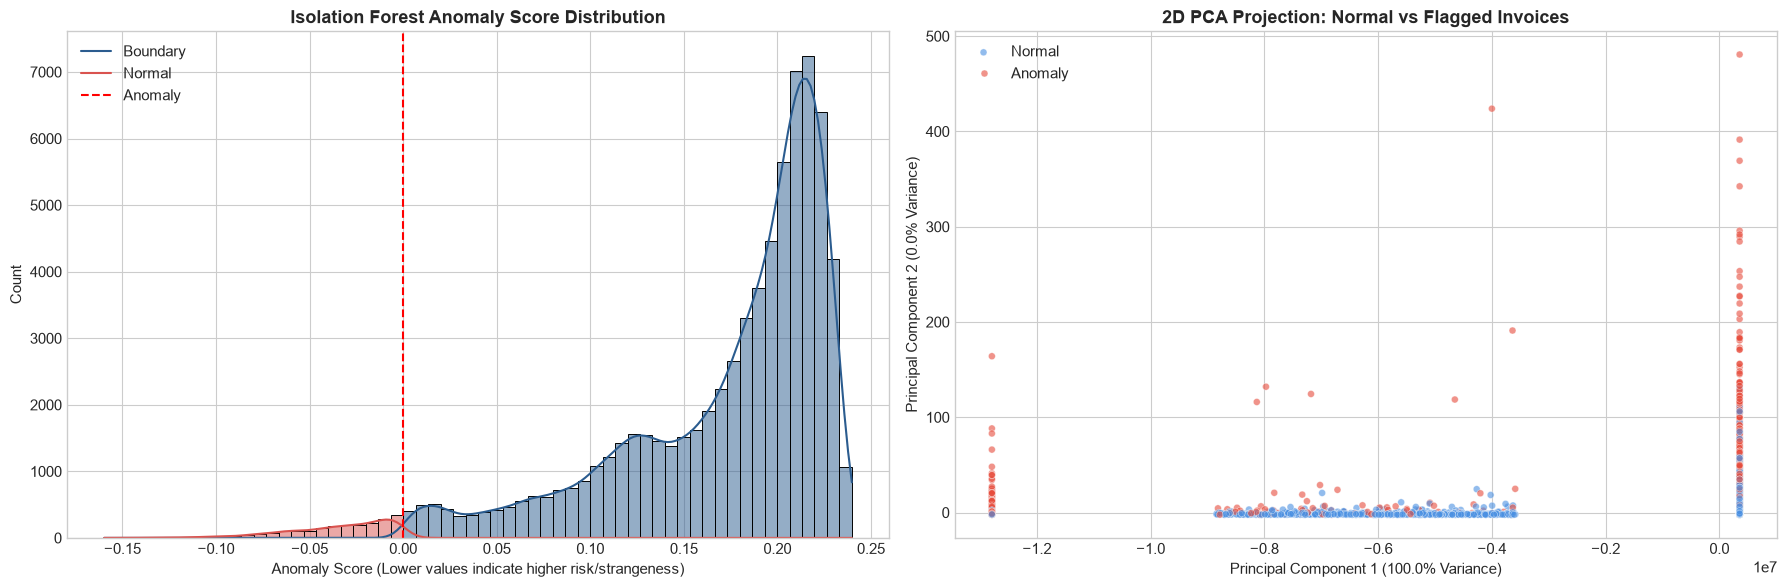

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Distribution of continuous anomaly scores
sns.histplot(
    data=df_invoices,
    x='anomaly_score',
    hue='anomaly_prediction',
    palette={1: '#2b5c8f', -1: '#d9534f'},
    bins=60,
    kde=True,
    ax=axes[0]
)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Decision Boundary (Score = 0.0)')
axes[0].set_title("Isolation Forest Anomaly Score Distribution", fontweight='bold')
axes[0].set_xlabel("Anomaly Score (Lower values indicate higher risk/strangeness)")
axes[0].legend(['Boundary', 'Normal', 'Anomaly'])

# 2. PCA 2D Dimensionality Reduction for Visual Inspection
pca = PCA(n_components=2, random_state=42)
X_scaled = pipeline.named_steps['scaler'].transform(X)
X_pca = pca.fit_transform(X_scaled)

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df_invoices['anomaly_prediction'],
    palette={1: '#4a90e2', -1: '#e74c3c'},
    alpha=0.6,
    s=25,
    ax=axes[1]
)
axes[1].set_title("2D PCA Projection: Normal vs Flagged Invoices", fontweight='bold')
axes[1].set_xlabel(f"Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% Variance)")
axes[1].set_ylabel(f"Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% Variance)")
axes[1].legend(['Normal', 'Anomaly'])

plt.tight_layout()
plt.show()

### 5.1 Root-Cause Audit: Top 10 Most Suspicious Invoices

In [17]:
top_anomalies = df_invoices[df_invoices['anomaly_prediction'] == -1].sort_values(by='anomaly_score').head(10)

audit_cols = [
    'invoice_id', 'customer_id', 'invoice_amount', 'discount_ratio',
    'credit_utilization_ratio', 'invoice_vs_customer_avg',
    'discount_vs_normal', 'average_item_price', 'anomaly_score'
]

print("⚠️ Top 10 High-Risk Invoices Flagged by Model:")
top_anomalies[audit_cols]

⚠️ Top 10 High-Risk Invoices Flagged by Model:


,invoice_id,customer_id,invoice_amount,discount_ratio,credit_utilization_ratio,invoice_vs_customer_avg,discount_vs_normal,average_item_price,anomaly_score
57539,INV-0064635,CUST-003158,34288.78,0.252746,0.074905,13.709299,-0.022361,352.581667,-0.159800
35032,INV-0065601,CUST-001909,31417.48,0.073275,0.097897,14.017153,-0.118325,244.663333,-0.144648
37031,INV-0049981,CUST-002010,14355.79,0.128176,0.167681,11.539092,-0.052440,494.916667,-0.141422
527,INV-0067786,CUST-000025,16224.31,0.201732,0.056133,8.805550,0.021644,208.545000,-0.140964
46355,INV-0064407,CUST-002518,13990.93,0.182588,0.388165,10.225078,0.045522,394.425000,-0.135101
33785,INV-0002078,CUST-001847,21338.42,0.100231,3.585168,7.958684,-0.031129,711.430000,-0.134360
13261,INV-0059180,CUST-000761,9843.57,0.033189,6.243899,6.043775,0.002473,408.345000,-0.133804
37217,INV-0056399,CUST-002020,16609.80,0.056202,0.801153,6.119347,0.030323,420.526667,-0.131502
40034,INV-0064276,CUST-002193,16585.95,0.130284,0.491879,8.406046,0.029202,234.730000,-0.129532
31870,INV-0069585,CUST-001757,13886.03,0.099989,1.251351,5.351470,0.014240,146.870000,-0.126875


## 6. 💾 Model Export & Production Pipeline Verification
Saving the trained pipeline (scaler + isolation forest) to `models/anomaly_detector.joblib` for direct integration with the FastAPI service.

In [18]:
MODELS_DIR = '../models'
os.makedirs(MODELS_DIR, exist_ok=True)

MODEL_PATH = os.path.join(MODELS_DIR, 'anomaly_detector.joblib')
joblib.dump(pipeline, MODEL_PATH)

print(f"💾 Pipeline successfully persisted to: {MODEL_PATH}")

# Verification: Reload the pipeline and run test inference
loaded_pipeline = joblib.load(MODEL_PATH)
test_batch = X.iloc[:3]
test_predictions = loaded_pipeline.predict(test_batch)
test_scores = loaded_pipeline.decision_function(test_batch)

print(f"🧪 Validation Test on 3 samples: Predictions = {test_predictions.tolist()} | Scores = {test_scores.round(4).tolist()}")

💾 Pipeline successfully persisted to: ../models\anomaly_detector.joblib
🧪 Validation Test on 3 samples: Predictions = [1, 1, 1] | Scores = [0.0859, 0.1283, 0.1554]
